# **Simulated Annealing**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2026. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

In [1]:
import numpy as np
from IPython.display import display
from matplotlib import pyplot as plt

# Simulated Annealing

We consider a function of the form
\begin{equation*}
f(x) = 
\left\{
\begin{array}{rl}
\displaystyle \sum_{i=0}^{n-1} \cos\left(\frac{1}{a_{i}x}\right)\sin\left(\frac{1}{x}\right), & \text{if } x \in [x_{\min}, x_{\max}],\\
0, & \text{otherwise},
\end{array}
\right.
\end{equation*}
for some strictly positive integer $n$ and some sequence $(a_{0},\ldots, a_{n-1}) \in\mathbb{R}^n$.

In [2]:
def f(x):
    """
    Function to be minimised or maximised
    x: input value
    note: this can be replaced by any function
    """
    fx = 0.
    if (x>=x_min) and (x<=x_max):
        for a in _aa:
            fx += np.cos(1./(a*x))*np.sin(1./x)
    return fx

### Plotting the function over $[x_{\min}, x_{\max}]$

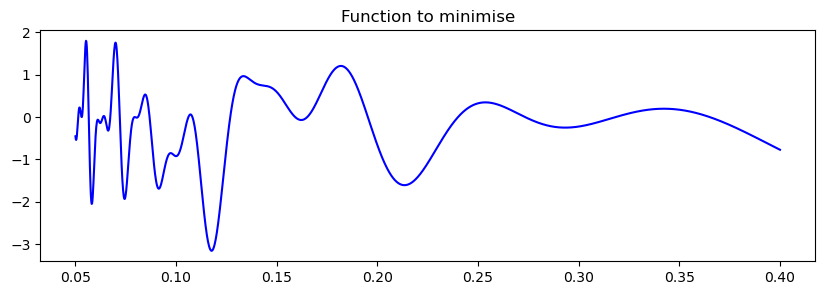

In [35]:
_aa = np.random.rand(5)

x_min, x_max = .05, .4
xx = np.linspace(x_min, x_max, 2000)
plt.figure(figsize=(10,3))
fxx = [f(x) for x in xx]
plt.plot(xx, fxx, 'b')
plt.title("Function to minimise")
plt.show()

The function above is plotted along a finite discrete grid, so we can look for the minimum and maximum directly (for comparison)

In [36]:
x_star_min = xx[np.argmin(fxx)]
x_star_max = xx[np.argmax(fxx)]
print("Minimum attained at ", np.round(x_star_min, 3), "with value", np.round(f(x_star_min), 3))
print("Maximum attained at ", np.round(x_star_max, 3), "with value", np.round(f(x_star_max), 3))

Minimum attained at  0.118 with value -3.159
Maximum attained at  0.055 with value 1.803


In [37]:
def derivf(x, epsilon):
    """
    Central finite-difference approximation of the derivative of the function
    x: value at which it is computed
    epsilon: bump amplitude
    """
    return (f(x + epsilon) - f(x - epsilon))/(2.*epsilon)

### Simulated annealing algorithm

Metaheuristic inspired by thermal annealing.

**Goal:** $\min_{\mathcal{D}\subset\mathbb{R}^n} f(x)$.

- Start with an initial value $x_{0}\in \mathcal{D}$ and compute $f(x_{0})$;
- Randomly choose a neighbour $\widetilde{x}$ of $x$ and evaluate $f(\widetilde{x})$;
- If $f(\widetilde{x}) < f(x_{0})$, then set $x_{1} := \widetilde{x}$;
- else, either keep $x_{1}=x_{0}$ as is or set $x_{1}:=\widetilde{x}$;
- Repeat over $n=1,2,\ldots$ until an end criterion is attained.

*Crucial step:* Step 4, to avoid being stuck in a local minimum and favouring, at least at the beginning of the algorithm, exploration rather than exploitation.

At step $n+1$: if 
$f(\widetilde{x}) \geq f(x_{n})$, we switch $x_{n+1} = \widetilde{x}$ with the probability
$$
\mathbb{P}(\textrm{switch}) = \exp\left\{-\frac{f(\widetilde{x}) - f(x_{n})}{\tau}\right\},
$$
where $\tau$ plays the role of the thermal annealing temperature: when the system is hot, particles move (exploration), and cools down when refinement (exploitation) is required.


Example of next step iteration (with $\eta>0$):
$$
x_{n+1} = x_{n} -\eta \ f'(x_n).
$$

Other example:
$$
x_{n+1} = x_{\min} + \mathcal{U}_{[0,1]}\Big(x_{\max} - x_{\min}\Big).
$$

In [38]:
def sa_next_step(x, x_min, x_max):
    return x_min + np.random.rand()*(x_max - x_min)


def sa_next_step_2(x, eta, x_min, x_max):
    _x = x + eta*derivf(x, 1E-4)
    
    if (_x<x_min) or (_x>x_max):
        _x = x_min + np.random.rand()*(x_max - x_min)
    return _x

def simul_annealing(f, x0, temperature, x_min, x_max):
    """
    Simulated annealing algorithm
    """

    x_seq = [x0]
    
    probas = [0.]
    outcomes = [0]

    for T in temperature:
        
        fx = f(x_seq[-1])
        
        x_new = sa_next_step(x_seq[-1], x_min, x_max)
        fx_new = f(x_new)
        
        if fx_new < fx: ## Better point
            x_seq.append(x_new)
            outcomes.append(0)
            probas.append(0.)
        else:
            proba_swap = np.exp(-(fx_new - fx)/T)
            random_proba = np.random.rand()
            
            if random_proba < proba_swap: ## swap
                x_seq.append(x_new)
                outcomes.append(1)
                probas.append(proba_swap)
            else:
                x_seq.append(x_seq[-1])
                outcomes.append(2)
                probas.append(0.)
                
    return x_seq, outcomes, probas

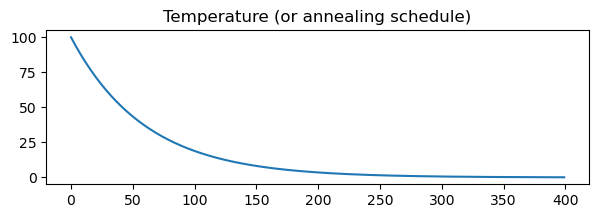

In [39]:
## Specify an annealing schedule
temperature = 100.*np.exp(-np.arange(400)/60)
#temperature = 100.*np.exp(-np.arange(100)/10)
plt.figure(figsize=(7,2))
plt.plot(temperature, '-')
plt.title("Temperature (or annealing schedule)")
plt.show()

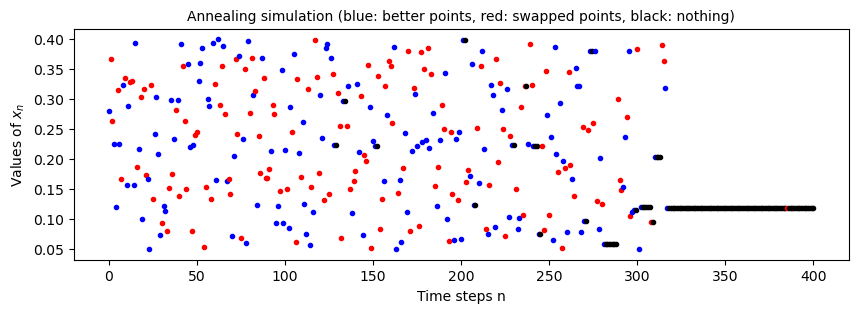

Minimum attained:  0.11844233895400166


In [40]:
## Pick a random starting point inside the domain
x0 = x_min + np.random.rand()*(x_max - x_min)

x_seq, outcomes, probas = simul_annealing(f, x0, temperature, x_min, x_max)

plt.figure(figsize=(10,3))
for (i,x) in enumerate(x_seq):
    if outcomes[i] == 0:
        plt.plot(i, x, 'b.')
    if outcomes[i] == 1:
        plt.plot(i, x, 'r.')
    if outcomes[i] == 2:
        plt.plot(i, x, 'k.')
#plt.plot(range(len(x_seq)), x_seq, 'b.', label="Valid")
plt.title("Annealing simulation (blue: better points, red: swapped points, black: nothing)", fontsize=10)
plt.xlabel("Time steps n")
plt.ylabel(r'Values of $x_n$')
plt.show()
print("Minimum attained: ", x_seq[-1])

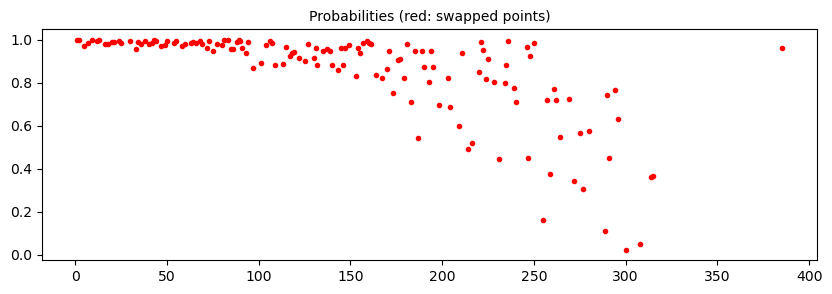

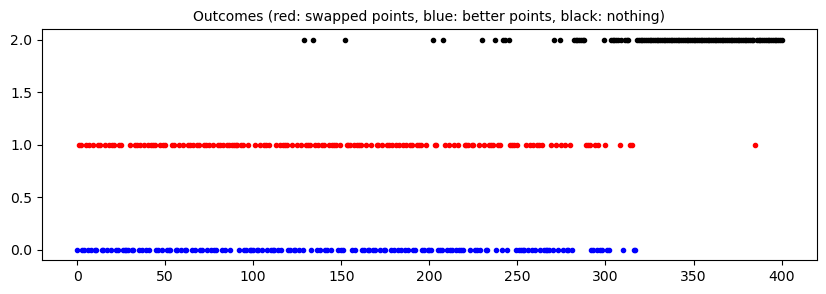

In [41]:
plt.figure(figsize=(10,3))
for (i,o) in enumerate(outcomes):
    if outcomes[i] == 1:
        plt.plot(i, probas[i], 'r.')
plt.title("Probabilities (red: swapped points)", fontsize=10)
plt.show()

plt.figure(figsize=(10,3))
for (i,o) in enumerate(outcomes):
    if outcomes[i] == 0:
        plt.plot(i, outcomes[i], 'b.')
    if outcomes[i] == 1:
        plt.plot(i, outcomes[i], 'r.')
    if outcomes[i] == 2:
        plt.plot(i, outcomes[i], 'k.')
plt.title("Outcomes (red: swapped points, blue: better points, black: nothing)", fontsize=10)
plt.show()

# Dynamic version

In [42]:
from IPython.display import clear_output 

f_seq = [f(x) for x in x_seq]
fxx = [f(x) for x in xx]

fx_star_max = f(x_star_max)
fx_star_min = f(x_star_min)
size_range = np.abs(fx_star_max - fx_star_min)

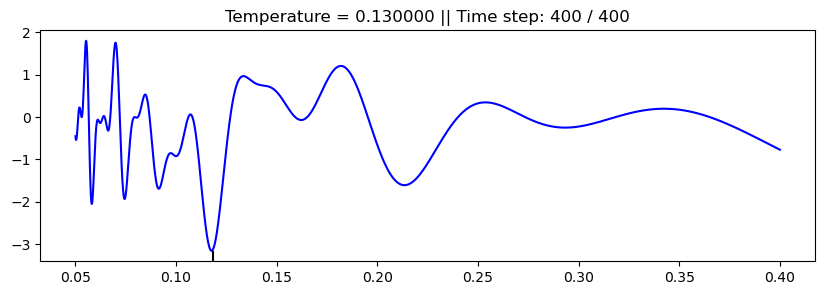

In [43]:
for (i,x) in enumerate(x_seq[:-1]):
    x, fx = x_seq[i], f_seq[i]
    plt.figure(figsize=(10,3))
    clear_output(wait=True)
    plt.title("Temperature = %.6f || Time step: %s / %s" %(np.round(temperature[i], 2), str(i+1),str(len(x_seq)-1)))
    i += 1
    plt.plot(xx, fxx, 'b')
    ymaxperc = .03 + np.abs(fx-fx_star_min) / size_range
    if outcomes[i] == 0:
        plt.axvline(x=x, ymin=0., ymax=ymaxperc, color='b')
    if outcomes[i] == 1:
        plt.axvline(x=x, ymin=0., ymax=ymaxperc, color='r')
    if outcomes[i] == 2:
        plt.axvline(x=x, ymin=0., ymax=ymaxperc, color='k')
    plt.show()